In [18]:
!git clone https://github.com/roaa108/DDPM_VAE.git
%cd DDPM_VAE
!pip install -q -r requirements.txt

Cloning into 'DDPM_VAE'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 39 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 31.90 KiB | 2.66 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/DDPM_VAE/DDPM_VAE


In [3]:
!nvidia-smi

Wed Sep  2 06:23:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!mkdir -p /content/drive/MyDrive/DDPM_VAE_runs/{checkpoints,results,data}
!rm -rf checkpoints results data
!ln -s /content/drive/MyDrive/DDPM_VAE_runs/checkpoints checkpoints
!ln -s /content/drive/MyDrive/DDPM_VAE_runs/results results
!ln -s /content/drive/MyDrive/DDPM_VAE_runs/data data
!ls -l

total 40
lrwxrwxrwx 1 root root   48 Sep  2 06:24 checkpoints -> /content/drive/MyDrive/DDPM_VAE_runs/checkpoints
lrwxrwxrwx 1 root root   41 Sep  2 06:24 data -> /content/drive/MyDrive/DDPM_VAE_runs/data
-rw-r--r-- 1 root root 1440 Sep  2 06:22 dataset.py
-rw-r--r-- 1 root root 7934 Sep  2 06:22 evaluate.py
drwxr-xr-x 3 root root 4096 Sep  2 06:22 experiments
drwxr-xr-x 3 root root 4096 Sep  2 06:22 models
-rw-r--r-- 1 root root 1016 Sep  2 06:22 plot_training.py
-rw-r--r-- 1 root root  110 Sep  2 06:22 README.md
-rw-r--r-- 1 root root  121 Sep  2 06:22 requirements.txt
lrwxrwxrwx 1 root root   44 Sep  2 06:24 results -> /content/drive/MyDrive/DDPM_VAE_runs/results
-rw-r--r-- 1 root root 6099 Sep  2 06:22 trainer.py


# 1- Train VAE

In [ ]:
# Trained for 100 epochs (VAE) and 400 epochs (DDPM) on an NVIDIA A100.

In [8]:
!python -m experiments.train_VAE

In [ ]:
!python -m experiments.train_ddpm     # re-run this cell to resume after a disconnect

In [15]:
!python plot_training.py --model vae
!python plot_training.py --model ddpm

Saved 3 plots to results/vae/
Saved 1 plots to results/ddpm/


In [16]:
!python evaluate.py --model vae
!python evaluate.py --model ddpm

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 306MB/s]
/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
{
  "model": "vae",
  "epoch": 91,
  "test_losses": {
    "test_reconstruction_loss": 117.14453656160379,
    "test_kl_divergence": 65.21447155143642,
    "test_total_loss": 182.35900859591328
  },
  "generation_metrics": {
    "fid": 134.02903

## Training outputs:

In [13]:
import json

for name in ["vae", "ddpm"]:
    h = json.load(open(f"checkpoints/{name}/history.json"))
    n = len(h["train_total_loss"])
    print(f"\n=== {name.upper()} — {n} epochs ===")
    for k in h:
        print(f"  {k:38s} first={h[k][0]:9.4f}  last={h[k][-1]:9.4f}")


=== VAE — 82 epochs ===
  train_reconstruction_loss              first= 350.0478  last= 115.3010
  train_kl_divergence                    first=  38.2991  last=  64.8886
  train_total_loss                       first= 388.3468  last= 180.1896
  validation_reconstruction_loss         first= 222.7207  last= 118.2802
  validation_kl_divergence               first=  46.9130  last=  64.9990
  validation_total_loss                  first= 269.6337  last= 183.2792

=== DDPM — 400 epochs ===
  train_total_loss                       first=   0.0768  last=   0.0294
  validation_total_loss                  first=   0.0466  last=   0.0307


### DDPM — generated samples

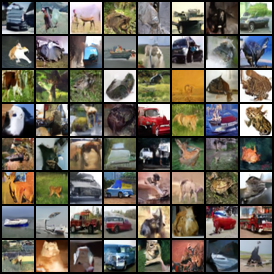

### VAE — generated samples

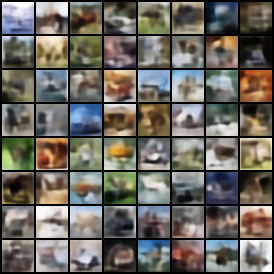

### VAE — reconstructions

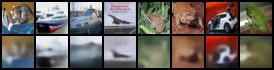

### VAE — latent interpolation

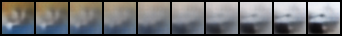

### VAE — KL per latent dimension

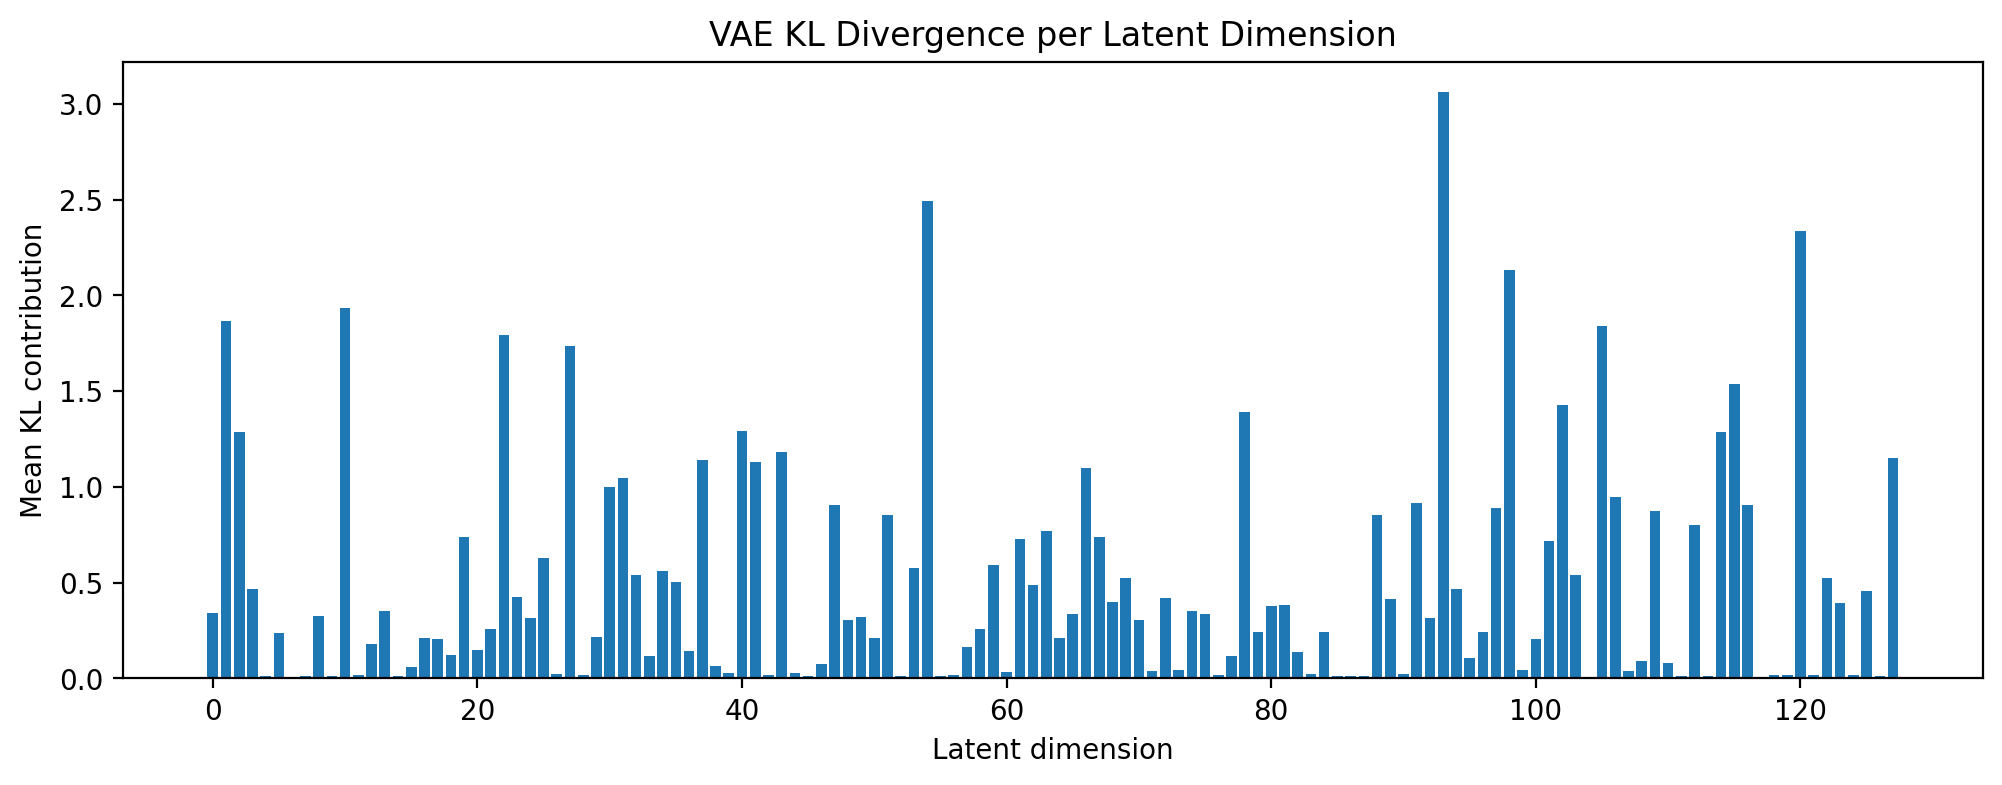

### DDPM — training loss

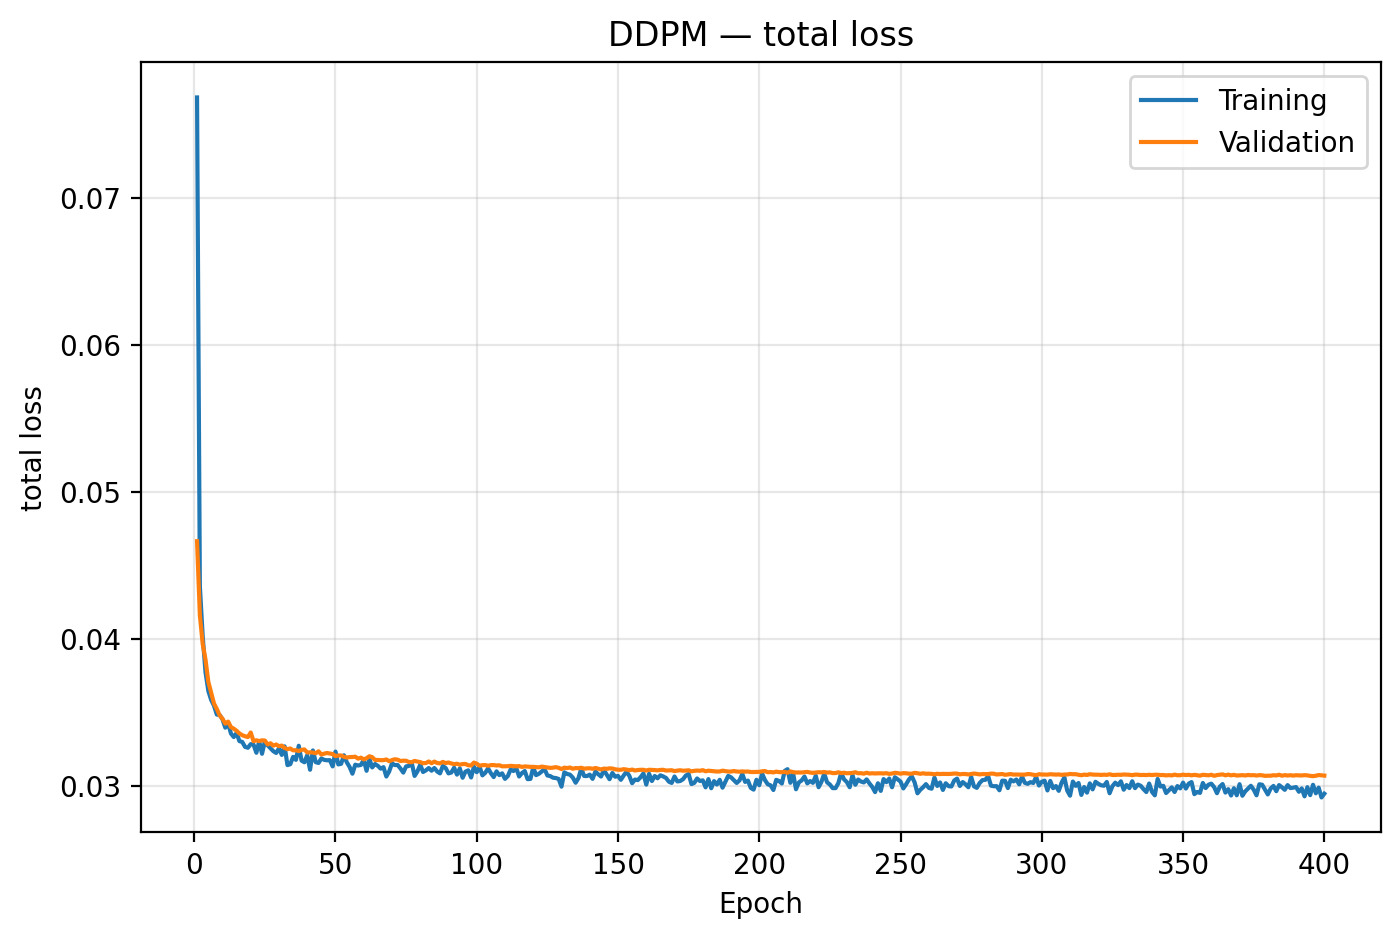

### VAE — training loss

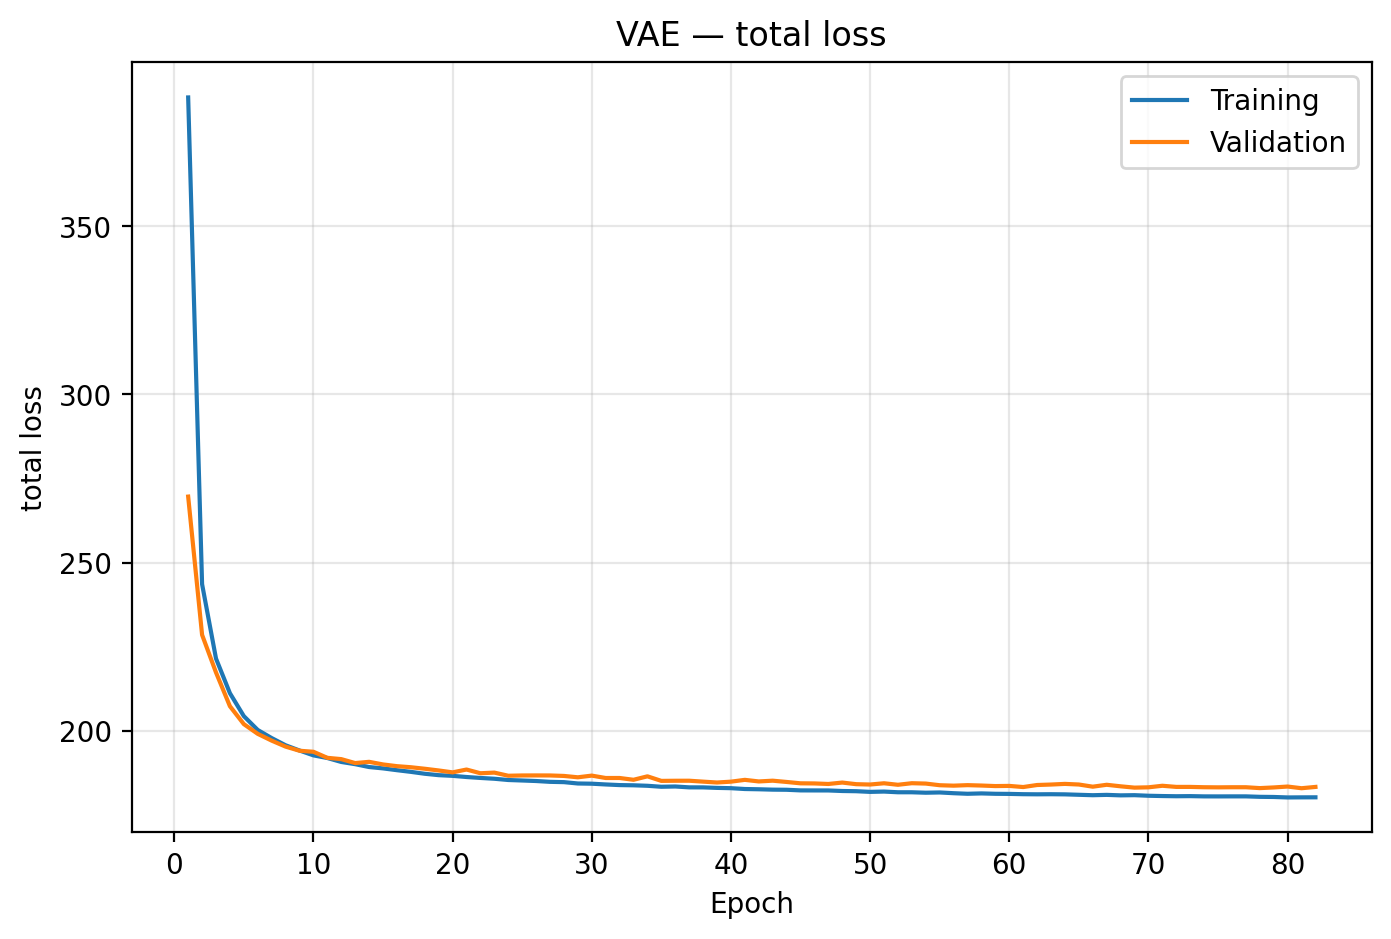

In [14]:
from IPython.display import Image, display, Markdown

figures = [
    ("DDPM — generated samples",        "results/ddpm/final/generation/final_samples.png"),
    ("VAE — generated samples",         "results/vae/final/generation/final_samples.png"),
    ("VAE — reconstructions",           "results/vae/final/reconstruction/final_reconstructions.png"),
    ("VAE — latent interpolation",      "results/vae/final/latent_space/latent_interpolation.png"),
    ("VAE — KL per latent dimension",   "results/vae/metrics/kl_per_dimension.png"),
    ("DDPM — training loss",            "results/ddpm/total_loss_curve.png"),
    ("VAE — training loss",             "results/vae/total_loss_curve.png"),
]

for title, path in figures:
    display(Markdown(f"### {title}"))
    display(Image(path))

##Final Comparison

In [17]:
import json, pandas as pd

rows = []
for name in ["vae", "ddpm"]:
    r = json.load(open(f"results/{name}/metrics/final_results.json"))
    g, t = r["generation_metrics"], r["generation_time"]
    rows.append({
        "model": name.upper(),
        "epoch": r["epoch"],
        "FID": round(g["fid"], 2),
        "KID": round(g["kid_mean"], 4),
        "IS": round(g["inception_score_mean"], 2),
        "images/sec": round(t["images_per_second"], 1),
    })

pd.DataFrame(rows)

,model,epoch,FID ↓,KID ↓,IS ↑,images/sec
0,VAE,91,134.03,0.1319,3.35,126954.6
1,DDPM,400,23.28,0.0162,7.29,10.7
